В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Area under ROC score on Train dataset: 0.88%
F1 score: 64.96%


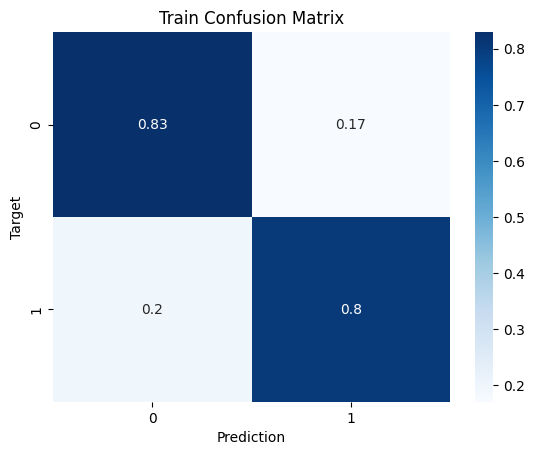

Area under ROC score on Validation dataset: 0.88%
F1 score: 63.38%


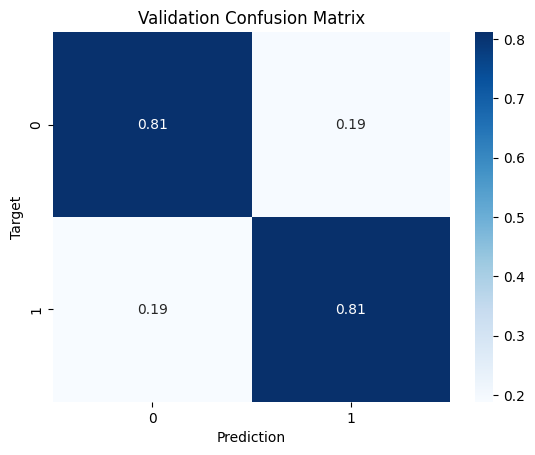

['bank_customer_churn.joblib']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay
import joblib

# Download the dataset
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

# Target column
target_col = 'Exited'

# Create training and validation sets
train_df, val_df = train_test_split(train_raw_df, test_size=0.2, random_state=42, stratify=train_raw_df[[target_col]])

# Create inputs and targets
input_cols = [col for col in train_df.columns[2:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=42))
])

# Train the model
model_pipeline.fit(train_inputs, train_targets)

# Helper function to predict, compute accuracy & plot confusion matrix
def predict_and_plot(inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # Probability
    prob = model_pipeline.predict_proba(inputs)[:,1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, prob)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")

    # F-1 Score
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1*100))

    # Confusion matrix
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Evaluate on validation and test set
train_preds = predict_and_plot(train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(val_inputs, val_targets, 'Validation')

# Save the trained model
joblib.dump(model_pipeline, 'bank_customer_churn.joblib')

In [ ]:
# Load the trained model
model_pipeline_loaded = joblib.load('bank_customer_churn.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 0.93%
F1 score: 70.56%


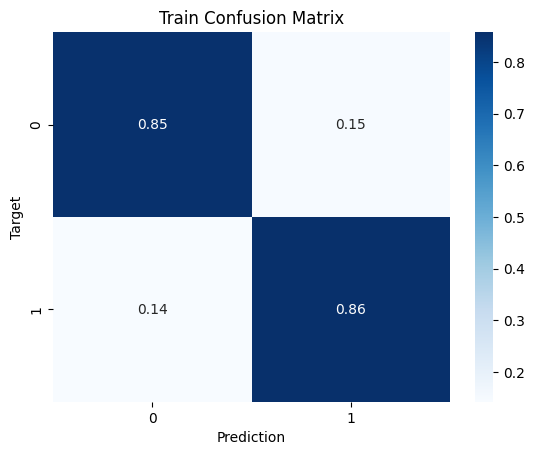

Area under ROC score on Validation dataset: 0.93%
F1 score: 69.54%


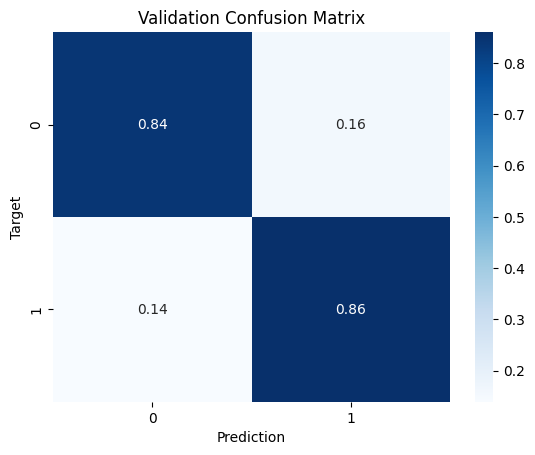

['bank_customer_churn_poly2.joblib']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay
import joblib

# Download the dataset
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

# Target column
target_col = 'Exited'

# Create training and validation sets
train_df, val_df = train_test_split(train_raw_df, test_size=0.2, random_state=42, stratify=train_raw_df[[target_col]])

# Create inputs and targets
input_cols = [col for col in train_df.columns[2:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer_poly2 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=2))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=42))
])

# Train the model
model_pipeline_poly2.fit(train_inputs, train_targets)

# Helper function to predict, compute accuracy & plot confusion matrix
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # Probability
    prob = model_pipeline.predict_proba(inputs)[:,1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, prob)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")

    # F-1 Score
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1*100))

    # Confusion matrix
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Evaluate on validation and test set
train_preds = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation')

# Save the trained model
joblib.dump(model_pipeline_poly2, 'bank_customer_churn_poly2.joblib')

Модель дала кращі результати, ніж модель без поліномінальних ознак.  
Для тренувальних та валідаційних даних бачимо однакові значення AUROC 0.93  
F1 Score для тренувальних даних 70.56%, для валідаційних - 69.54%  
overfit не спостерігається, оскільки AUROC однакові

In [34]:
model_pipeline_loaded = joblib.load('bank_customer_churn_poly2.joblib')

In [48]:
test_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/test.csv')
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')

X_test = test_df[train_inputs.columns]
submission_log_reg_df["Exited"] = model_pipeline_poly4.predict_proba(X_test)[:,1]

save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.94%
F1 score: 71.71%


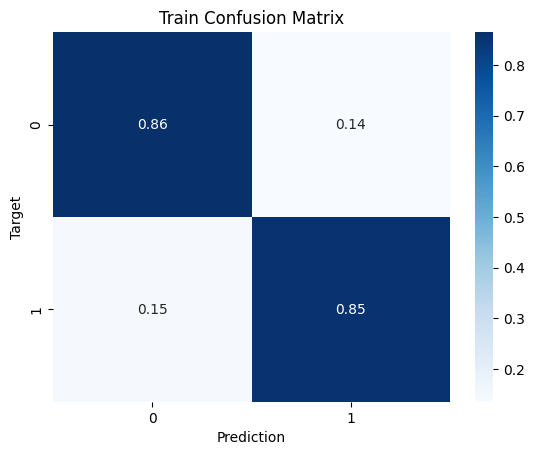

Area under ROC score on Validation dataset: 0.93%
F1 score: 71.25%


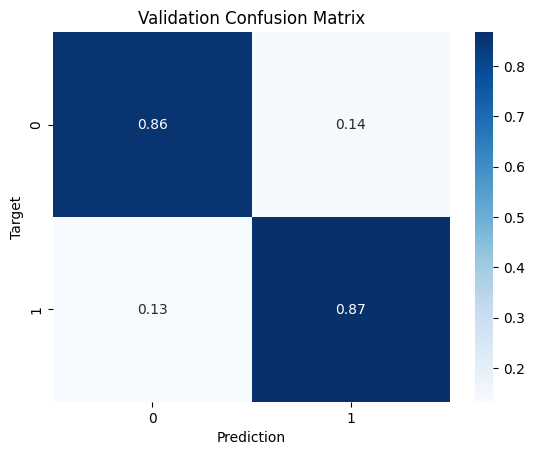

['bank_customer_churn_poly4.joblib']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay
import joblib

# Download the dataset
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

# Target column
target_col = 'Exited'

# Create training and validation sets
train_df, val_df = train_test_split(train_raw_df, test_size=0.2, random_state=42, stratify=train_raw_df[[target_col]])

# Create inputs and targets
input_cols = [col for col in train_df.columns[2:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=4))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=42))
])

# Train the model
model_pipeline_poly4.fit(train_inputs, train_targets)

# Helper function to predict, compute accuracy & plot confusion matrix
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # Probability
    prob = model_pipeline.predict_proba(inputs)[:,1]

    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, prob)

    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")

    # F-1 Score
    f1 = f1_score(targets, preds)
    print("F1 score: {:.2f}%".format(f1*100))

    # Confusion matrix
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Evaluate on validation and test set
train_preds = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')

# Save the trained model
joblib.dump(model_pipeline_poly4, 'bank_customer_churn_poly4.joblib')

Для тренувальних та валідаційних даних бачимо різні близькі значення AUROC:  
- 0.94 для тренувальних даних
- 0.93 для валідаційних даних
Спостерігається overfit оскільки AUROC для валідаційних даних менша, отже модель перевчилася і недостатньо узагальнює

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [7]:
# Download the dataset
regression_data_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/regression_data.csv')

In [14]:
regression_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  129 non-null    float64
 1   feature_2  129 non-null    float64
 2   feature_3  129 non-null    float64
 3   feature_4  129 non-null    float64
 4   feature_5  129 non-null    float64
 5   target     129 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB


In [15]:
regression_data_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


Всі колонки вже числові, тому використати потрібно лише scaler

In [68]:
# Helper function to predict, compute accuracy
def linear_reg_predict(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    # R^2 Score
    r2 = r2_score(targets, preds)
    print("{} R^2 score: {:.2f}".format(name, r2))

    # RMSE
    rmse = root_mean_squared_error(targets, preds)
    print("{} RMSE: {:.2f}".format(name, rmse))

    # STD
    print("{} targets std: {:.2f}".format(name, np.std(targets)))
    return preds

Train R^2 score: 1.00
Train RMSE: 0.00
Train targets std: 44.13
Test R^2 score: 0.87
Test RMSE: 17.35
Test targets std: 48.30


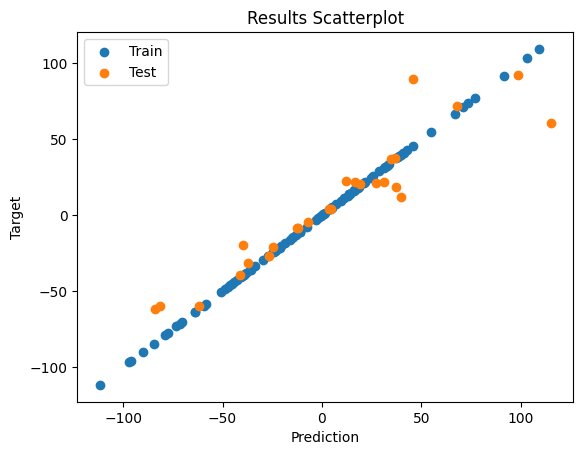

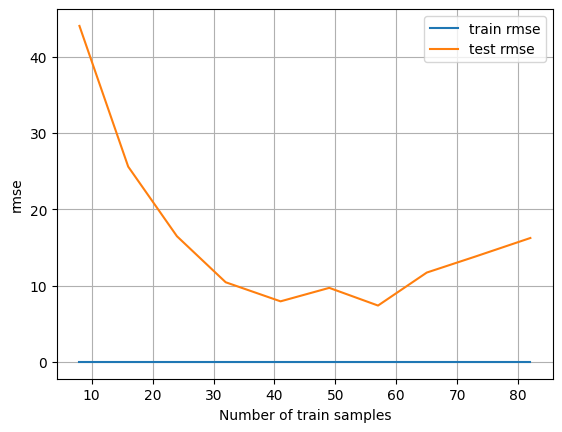

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib

# Download the dataset
regression_data_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/regression_data.csv')

# Target column
target_col = 'target'

# Create training and validation sets
train_df, test_df = train_test_split(regression_data_df, test_size=0.2, random_state=42)

# Create inputs and targets
input_cols = [col for col in train_df.columns[:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer_poly5 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=5))
])

# Preprocessor
preprocessor_poly5 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly5, numeric_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline_poly5 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly5),
    ('regressor', LinearRegression())
])

# Train the model
model_pipeline_poly5.fit(train_inputs, train_targets)

# Evaluate on validation and test set
train_preds = linear_reg_predict(model_pipeline_poly5, train_inputs, train_targets, 'Train')
test_preds = linear_reg_predict(model_pipeline_poly5, test_inputs, test_targets, 'Test')

# Plot with results
plt.figure()
plt.scatter(train_targets, train_preds, label='Train')
plt.scatter(test_targets, test_preds, label='Test')
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Results Scatterplot')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(model_pipeline_poly5, 'regression_poly5.joblib')

# Building learning curve for RMSE
train_sizes = np.linspace(0.1, 1.0, 10)

sizes, tr, va = learning_curve(
    model_pipeline_poly5,
    train_inputs, train_targets,
    train_sizes=train_sizes,
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=42
)

train_rmse = -tr.mean(axis=1)
test_rmse = -va.mean(axis=1)

plt.figure()
plt.plot(sizes, train_rmse, label="train rmse")
plt.plot(sizes, test_rmse, label="test rmse")
plt.xlabel("Number of train samples")
plt.ylabel("rmse")
plt.grid()
plt.legend()
plt.show()

За результатами моделі на тренувальних та тестових даних видно, що модель перенавчилася (overfit):  
- на тренувальних даних модель має ідеальні показники (R^2 score: 1.00,  RMSE: 0.00)  
- на тестових - нижчі показники (R^2 score: 0.87, RMSE: 17.35)

Модель майже ідеально підлаштована під тренувальні дані, а на тестових показує гірше узагальнення.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

LinearRegression Train R^2 score: 1.00
LinearRegression Train RMSE: 0.00
LinearRegression Train targets std: 44.13
LinearRegression Test R^2 score: 0.93
LinearRegression Test RMSE: 12.73
LinearRegression Test targets std: 48.30


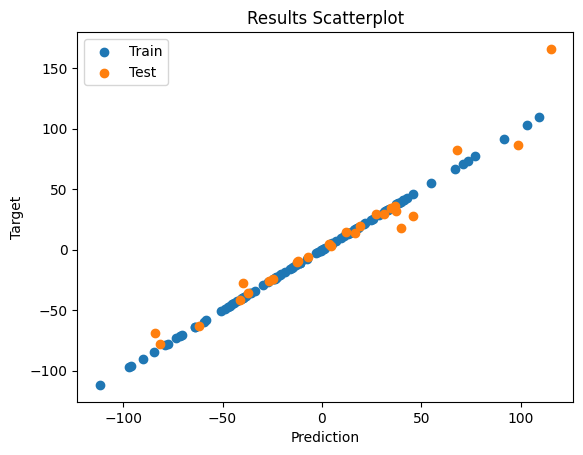

Model saved as: LinearRegression_poly20.joblib


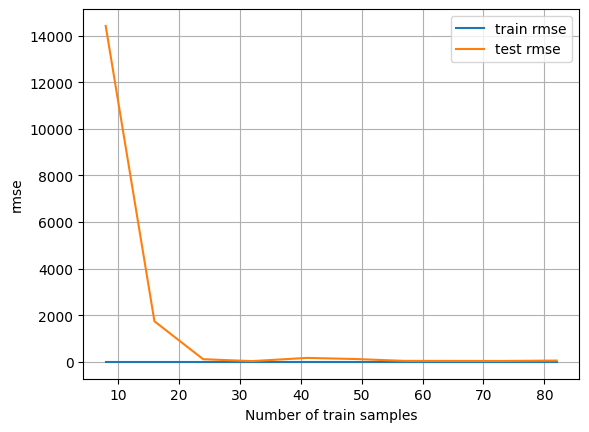

Ridge Train R^2 score: 0.98
Ridge Train RMSE: 5.89
Ridge Train targets std: 44.13
Ridge Test R^2 score: 0.98
Ridge Test RMSE: 7.02
Ridge Test targets std: 48.30


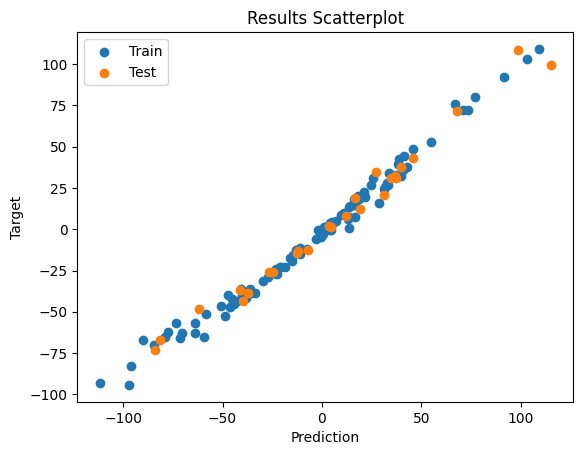

Model saved as: Ridge_poly20.joblib


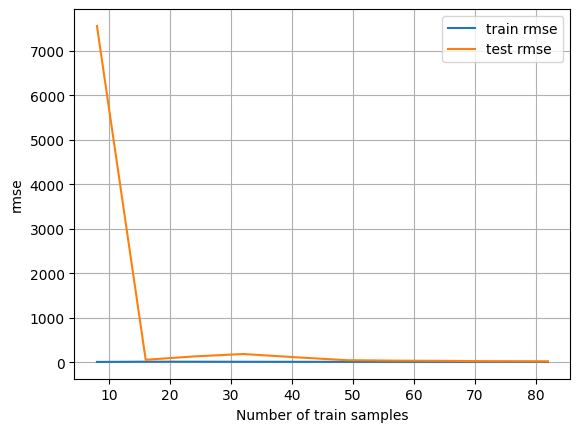

Ridge Train R^2 score: 0.97
Ridge Train RMSE: 7.92
Ridge Train targets std: 44.13
Ridge Test R^2 score: 0.97
Ridge Test RMSE: 8.61
Ridge Test targets std: 48.30


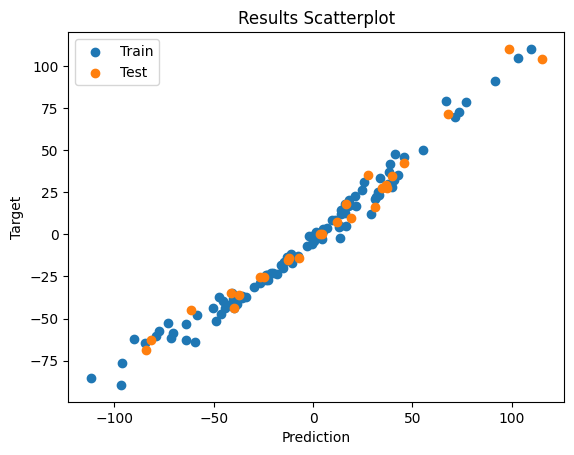

Model saved as: Ridge_poly20.joblib


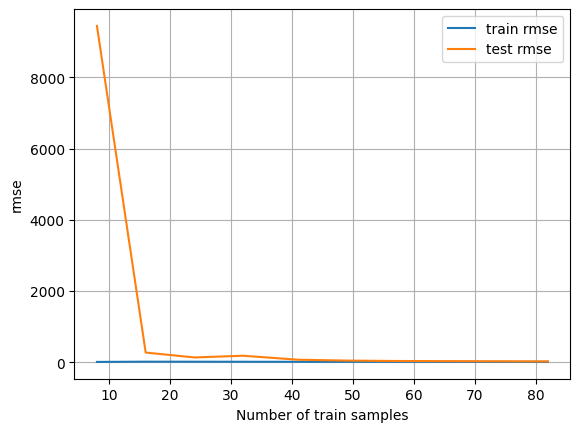

Lasso Train R^2 score: 0.99
Lasso Train RMSE: 5.10
Lasso Train targets std: 44.13
Lasso Test R^2 score: 0.99
Lasso Test RMSE: 5.67
Lasso Test targets std: 48.30


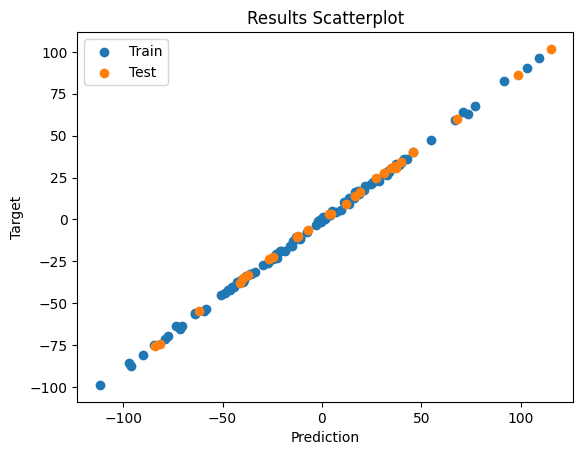

Model saved as: Lasso_poly20.joblib


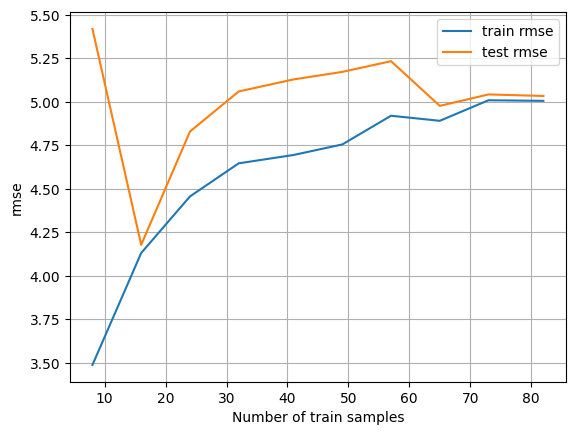

ElasticNet Train R^2 score: 0.54
ElasticNet Train RMSE: 30.03
ElasticNet Train targets std: 44.13
ElasticNet Test R^2 score: 0.60
ElasticNet Test RMSE: 30.44
ElasticNet Test targets std: 48.30


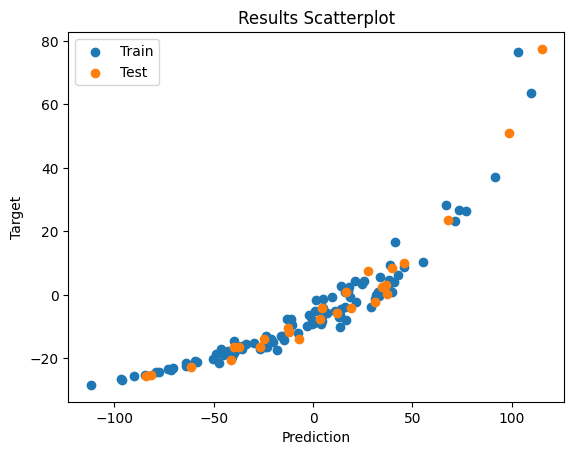

Model saved as: ElasticNet_poly20.joblib


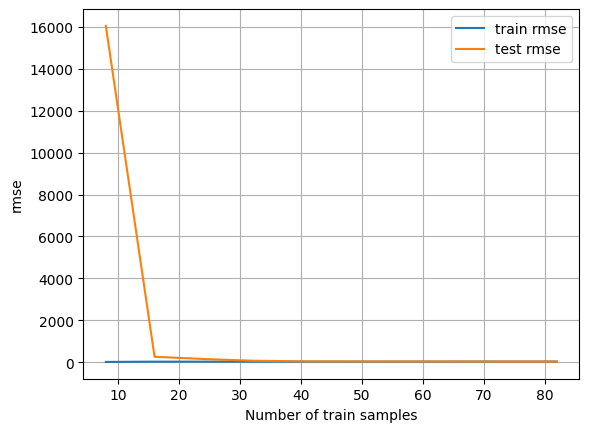

ElasticNet Train R^2 score: 0.71
ElasticNet Train RMSE: 23.84
ElasticNet Train targets std: 44.13
ElasticNet Test R^2 score: 0.77
ElasticNet Test RMSE: 23.30
ElasticNet Test targets std: 48.30


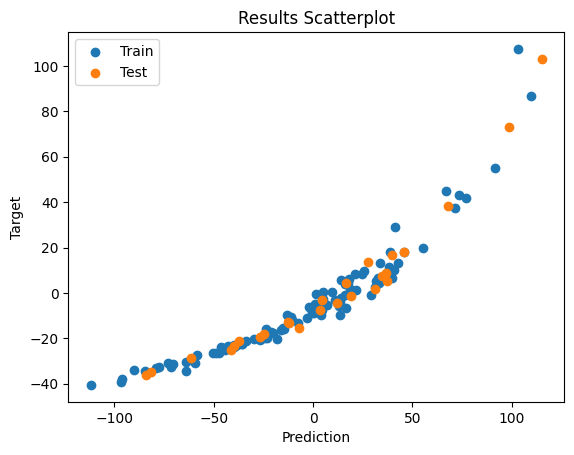

Model saved as: ElasticNet_poly20.joblib


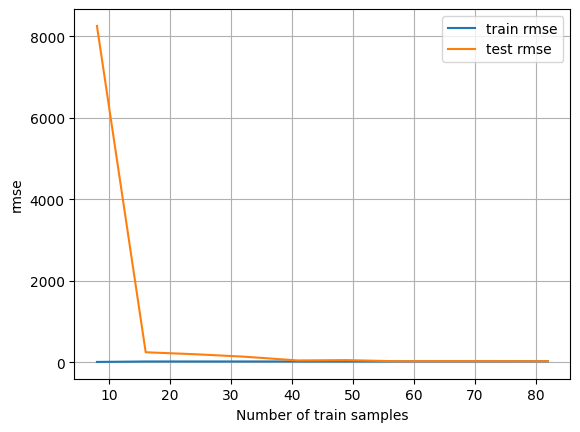

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib

# Download the dataset
regression_data_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/regression_data.csv')

# Target column
target_col = 'target'

# Create training and validation sets
train_df, test_df = train_test_split(regression_data_df, test_size=0.2, random_state=42)

# Create inputs and targets
input_cols = [col for col in train_df.columns[:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer_poly20 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=20))
])

# Preprocessor
preprocessor_poly20 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly20, numeric_cols)
    ])

# Models list
models = [
    LinearRegression(),
    Ridge(),
    Ridge(alpha=2),
    Lasso(),
    ElasticNet(),
    ElasticNet(alpha=0.5)
]

# Create a pipelines that include preprocessing and the model for each of models
pipelines = {}
for model in models:
  name = model.__class__.__name__
  pipe = Pipeline(steps=[
      ('preprocessor', preprocessor_poly20),
      ('regressor', model)
  ])

  # Train the model
  pipe.fit(train_inputs, train_targets)
  pipelines[name]=pipe

  # Evaluate on validation and test set
  train_preds = linear_reg_predict(pipe, train_inputs, train_targets, f'{name} Train')
  test_preds = linear_reg_predict(pipe, test_inputs, test_targets, f'{name} Test')

  # Plot with results
  plt.figure()
  plt.scatter(train_targets, train_preds, label='Train')
  plt.scatter(test_targets, test_preds, label='Test')
  plt.xlabel('Prediction')
  plt.ylabel('Target')
  plt.title('Results Scatterplot')
  plt.legend()
  plt.show()

  # # Save the trained model
  filename = f'{name}_poly20.joblib'
  joblib.dump(pipe, filename)
  print(f'Model saved as: {filename}')
  # joblib.dump(model_pipeline_poly20, 'regression_poly20.joblib')

  # Building learning curve for RMSE
  train_sizes = np.linspace(0.1, 1.0, 10)

  sizes, tr, va = learning_curve(
      pipe,
      train_inputs, train_targets,
      train_sizes=train_sizes,
      cv=5,
      scoring="neg_root_mean_squared_error",
      shuffle=True,
      random_state=42
  )

  train_rmse = -tr.mean(axis=1)
  test_rmse = -va.mean(axis=1)

  plt.figure()
  plt.plot(sizes, train_rmse, label="train rmse")
  plt.plot(sizes, test_rmse, label="test rmse")
  plt.xlabel("Number of train samples")
  plt.ylabel("rmse")
  plt.grid()
  plt.legend()
  plt.show()

Отримано наступні оцінки для моделей:  

**LinearRegression poly=2**  
Train R^2 score: 1.00  
Train RMSE: 0.00  
Test R^2 score: 0.87  
Test RMSE: 17.35  

**LinearRegression poly=20**  
Train R^2 score: 1.00  
Train RMSE: 0.00  
Test R^2 score: 0.93  
Test RMSE: 12.73  

**Ridge**  
Train R^2 score: 0.98  
Train RMSE: 5.89  
Test R^2 score: 0.98  
Test RMSE: 7.02  

**Ridge(alpha=2)**  
Train R^2 score: 0.97  
Train RMSE: 7.92  
Test R^2 score: 0.97  
Test RMSE: 8.61  

**Lasso**    
Train R^2 score: 0.99  
Train RMSE: 5.10  
Test R^2 score: 0.99  
Test RMSE: 5.67  

**ElasticNet**   
Train R^2 score: 0.54  
Train RMSE: 30.03  
Test R^2 score: 0.60  
Test RMSE: 30.44  

**ElasticNet(alpha=0.5)**   
Train R^2 score: 0.71  
Train RMSE: 23.84  
Test R^2 score: 0.77  
Test RMSE: 23.30  


- Для лінійної регресії зі степенем 20 оверфіт також спостерігається  
- Найкраще значення R^2 (0.99) та мінімальні RMSE (5.10, 5.67) для моделі Lasso(), також на кривих навчання видно явну збіжність значень rmse з кожним наступним зразком у наборі даних. Також видно на графіку, що точки, передбачені з тренувального та тестового набору, лягають найкраще один на одного порівняно з графіками для інших моделей
- Андерфіти для моделей ElasticNet (R^2 для тренувальних даних менший, ніж для тестових)
- Оптимальний фіт для моделей Rigde, але нижчі показники якості моделей (менші R^2, більші RMSE)